In [1]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Step 2: Load the Iris Dataset
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Rename columns to cleaner names
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

# View first 5 rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# Step 3: Basic EDA
print("Shape of dataset:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

print("\nBasic Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSpecies Count:")
print(df['species'].value_counts())

Shape of dataset:
(150, 5)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None

Basic Statistics:
       sepal_length  sepal_width  petal_length  petal_width     species
count    150.000000   150.000000    150.000000   150.000000  150.000000
mean       5.843333     3.057333      3.758000     1.199333    1.000000
std        0.828066     0.435866      1.765298     0.762238    0.819232
min        4.300000     2.000000      1.000000     0.100000    0.000000
25%        5.100000     2.800000      1.600000     0.300000    0.000000
50%        5.800000     3.000000      4.350000 

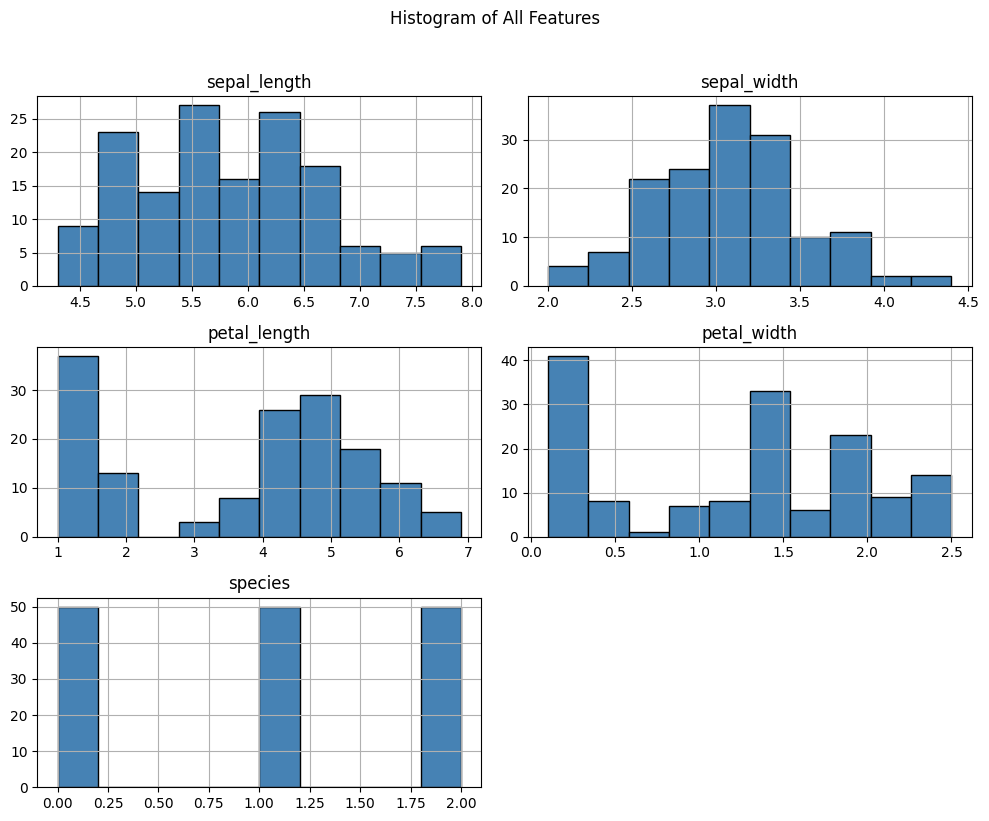

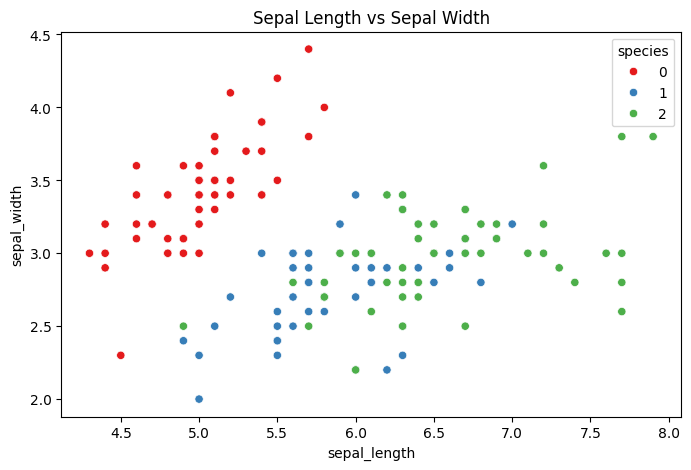

/tmp/ipykernel_3503/98758952.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='petal_length', palette='Set2')


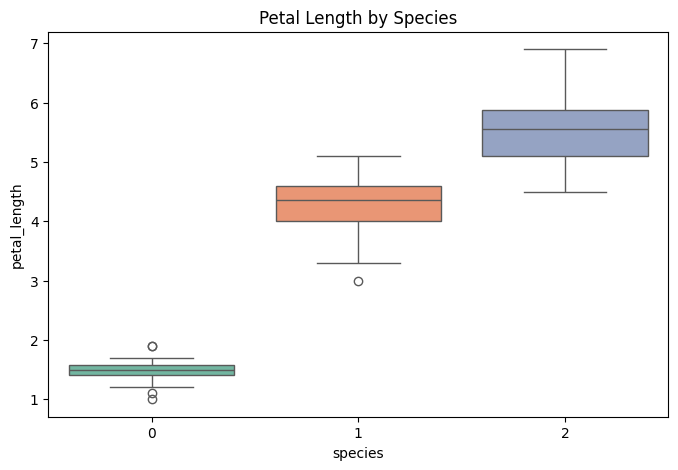

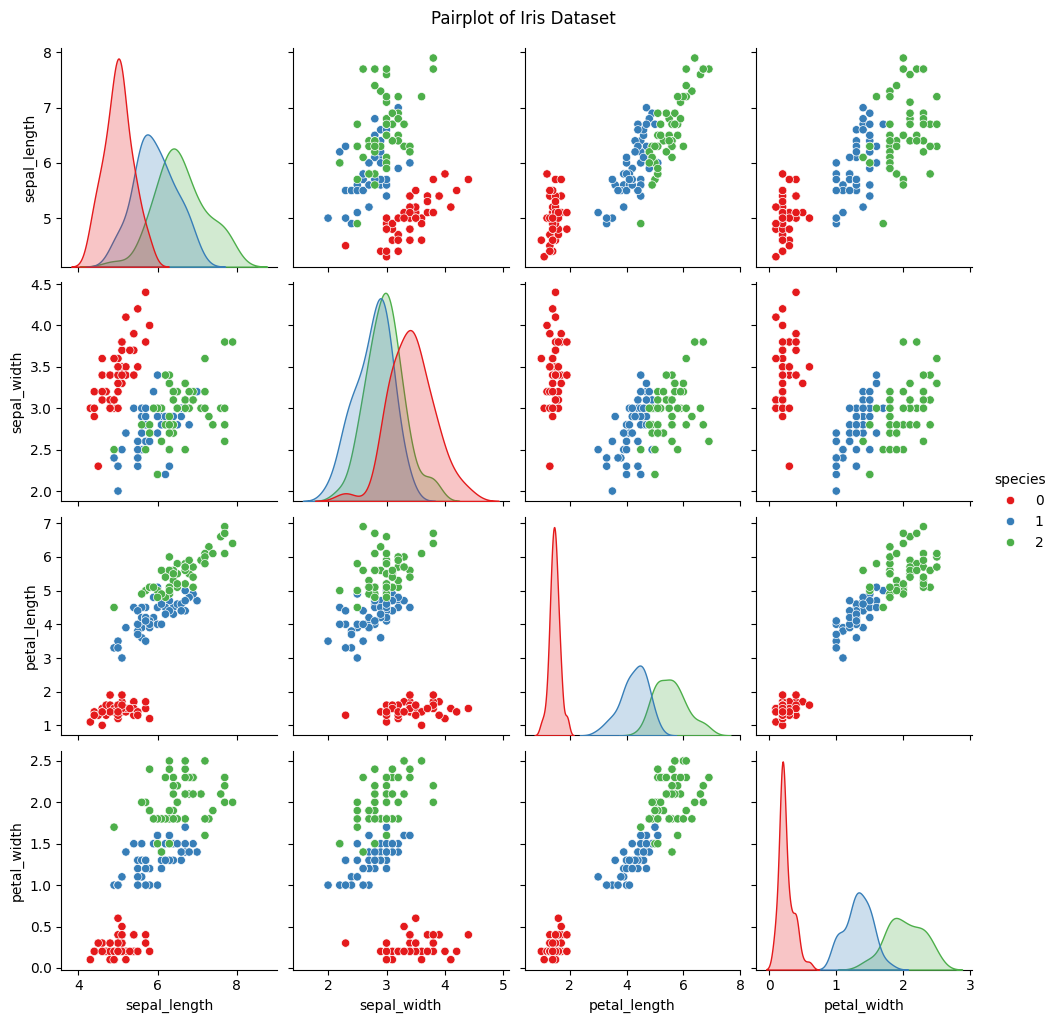

In [4]:
# Step 4: Visualizations

# Graph 1: Histogram
df.hist(figsize=(10,8), color='steelblue', edgecolor='black')
plt.suptitle('Histogram of All Features', y=1.02)
plt.tight_layout()
plt.show()

# Graph 2: Scatter Plot
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='species', palette='Set1')
plt.title('Sepal Length vs Sepal Width')
plt.show()

# Graph 3: Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='species', y='petal_length', palette='Set2')
plt.title('Petal Length by Species')
plt.show()

# Graph 4: Pairplot
sns.pairplot(df, hue='species', palette='Set1')
plt.suptitle('Pairplot of Iris Dataset', y=1.02)
plt.show()

In [5]:
# Step 5: Train the Model

# Split data into features (X) and target (y)
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


Accuracy Score: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



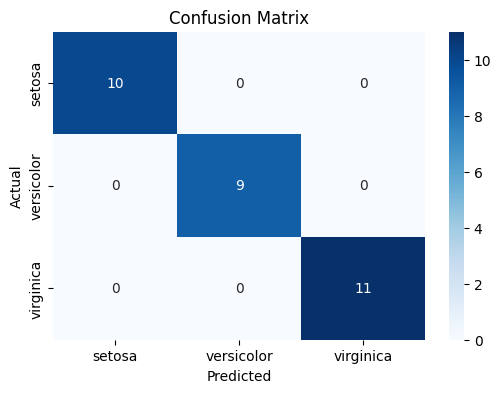

In [6]:
# Step 6: Evaluate the Model

# Make predictions
y_pred = model.predict(X_test)

# Accuracy Score
print("Accuracy Score:", accuracy_score(y_test, y_pred))

# Detailed Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [7]:
# Step 7: Save the Model
import joblib

joblib.dump(model, 'iris_model.pkl')
print("✅ Model saved as iris_model.pkl")

✅ Model saved as iris_model.pkl


In [8]:
# Step 8: Download the model file
from google.colab import files

files.download('iris_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>